In [56]:
import nltk
import json
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as px


from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from nltk.tokenize import word_tokenize

from storage.database import Database
from gensim.models import Word2Vec

In [47]:
DATABASE_PATH = "../data.db"
QUANTITY = 10000
CAMPOS_ID =("id", "id_discurso")
database = Database(DATABASE_PATH)
query = "educacao publica investimento escolas professores"

try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')
    
nltk.download('rslp')
nltk.download('punkt_tab')

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\micael.conti\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\micael.conti\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Zip Slip blocked: punkt_tab/


False

## Métodos

In [4]:
def mostrar_tabela(x,vec,title):
    df_bow = pd.DataFrame(x.toarray(), columns=vec.get_feature_names_out())
    print(title)
    display(df_bow)

In [7]:
def get_corpus(documentos, campo, campos_id=("id", "id_doc")):
    corpus = []
    doc_ids = []

    for d in documentos:
        if campo in d and d[campo]:
            corpus.append(json.loads(d[campo]))
            
            id_composto = "_".join(str(d[c]) for c in campos_id)
            doc_ids.append(id_composto)

    return corpus, doc_ids

In [20]:
def get_discursos_corpus(campo, campos_id, size):
    discursos = database.get_discursos(size)
    return get_corpus(discursos, campo, campos_id)

In [19]:
def processar_dados_bow(corpus):    
    bow_vec = CountVectorizer(
        lowercase=False,
        preprocessor=None,
        tokenizer=lambda x: x
    )
    
    X_bow = bow_vec.fit_transform(corpus)
    
    return X_bow, bow_vec

In [24]:
def processar_dados_td_idf(corpus):
    tfidf_vec = TfidfVectorizer(
        lowercase=False,
        preprocessor=None,
        tokenizer=lambda x: x
    )
    
    X_tfidf = tfidf_vec.fit_transform(corpus)
    
    return X_tfidf, tfidf_vec

In [10]:
def search_and_rank(query, vectorizer, X_corpus, corpus, doc_ids, method_name):
    """
    Vetoriza uma query, calcula a similaridade com o corpus e exibe os resultados.
    """
    q_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(q_vec, X_corpus).ravel()
    rank = np.argsort(sim_scores)[::-1]

    print(f"Top-3 Similares para a Query (usando {method_name}):")
    for i in rank[:3]:
        if sim_scores[i] > 0.01: # Apenas mostra se houver alguma similaridade
            print(f"  Doc{doc_ids[i]} (score={sim_scores[i]:.3f}): {corpus[i]}")
    print("-" * 40)

In [39]:
def matriz_similaridade_top_n(dados, doc_ids, top_n, subtitle = ""):
    sim_matrix = cosine_similarity(dados, dados)

    sim_no_diag = sim_matrix.copy()
    np.fill_diagonal(sim_no_diag, 0)

    mean_sim = sim_no_diag.mean(axis=1)
    top_idxs = np.argsort(mean_sim)[::-1][:top_n]

    sub_sim = sim_matrix[np.ix_(top_idxs, top_idxs)]
    
    if doc_ids is None:
        doc_ids = np.arange(len(dados))

    doc_labels = np.array(doc_ids)[top_idxs]
    df_similarity = pd.DataFrame(sub_sim, index=doc_labels, columns=doc_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(df_similarity, annot=True, cmap="Blues", fmt=".2f")
    plt.title(f"Heatmap dos {top_n} documentos mais semelhantes - {subtitle}")
    plt.xlabel("Documentos")
    plt.ylabel("Documentos")
    plt.tight_layout()
    plt.show()

In [12]:
def grafico2D(dados):
    pca = PCA(n_components=2)
    X_tfidf_pca = pca.fit_transform(dados.toarray())

    plt.figure(figsize=(10, 7))
    plt.scatter(X_tfidf_pca[:, 0], X_tfidf_pca[:, 1], c='blue', alpha=0.7, s=100)
    plt.title("Visualização 2D dos Vetores de Documentos")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.grid(True)

    plt.show()

In [13]:
def grafico3D(dados):
    # Redução de dimensionalidade
    pca = PCA(n_components=3)
    X_tfidf_pca = pca.fit_transform(dados.toarray())

    # Criando gráfico 3D com Plotly Express
    fig = px.scatter_3d(
        x=X_tfidf_pca[:, 0],
        y=X_tfidf_pca[:, 1],
        z=X_tfidf_pca[:, 2],
        opacity=0.7,
        title="Visualização 3D dos Vetores de Documentos"
    )

    # Ajustando labels
    fig.update_layout(
        scene=dict(
            xaxis_title="Componente Principal 1",
            yaxis_title="Componente Principal 2",
            zaxis_title="Componente Principal 3"
        )
    )

    fig.show()

In [44]:
def calcula_vetor_medio(corpus, modelo, vector_dim):
    vetores_documentos = []
    
    for doc_tokens in corpus:
        # Pega os vetores das palavras no documento que existem no modelo
        vetores_palavras = [modelo.wv[palavra] for palavra in doc_tokens if palavra in modelo.wv]

        if len(vetores_palavras) > 0:
            # Calcula a média dos vetores das palavras
            vetor_medio_doc = np.mean(vetores_palavras, axis=0)
            vetores_documentos.append(vetor_medio_doc)
        else:
            # Se nenhuma palavra do documento estiver no vocabulário, adiciona um vetor de zeros
            # (Isso é raro com min_count=1, mas é bom ter por segurança)
            print(f"Aviso: Documento '{' '.join(doc_tokens)}' não possui palavras no vocabulário do modelo.")
            vetores_documentos.append(np.zeros(vector_dim))

    # Garantir que temos um array NumPy
    return np.array(vetores_documentos)

In [51]:
def recomendar_documentos_w2v(consulta, model_w2v, documentos_originais, vetores_documentos, num_resultados=None):
    """
    Recomenda documentos com base na similaridade semântica (Word2Vec) com a consulta.

    Args:
        consulta (str): O termo ou frase de busca do usuário.
        model_w2v (gensim.models.Word2Vec): O modelo Word2Vec treinado.
        documentos_originais (list): Lista das strings dos documentos originais.
        vetores_documentos (np.ndarray): Array NumPy com os vetores médios pré-calculados
                                         para cada documento original.
        num_resultados (int, optional): Número máximo de resultados a retornar.
                                         Se None, retorna todos. Defaults to None.

    Returns:
        pd.DataFrame: DataFrame com colunas 'Documento' e 'Similaridade',
                      ordenado por similaridade decrescente. Retorna DataFrame vazio
                      se a consulta não puder ser vetorizada (nenhuma palavra conhecida).
    """
    # 1. Preprocessar (tokenizar, lowercase) a consulta
    tokens_busca = word_tokenize(consulta.lower())
    
    if not tokens_busca:
        print("Aviso: Consulta vazia após tokenização.")
        return pd.DataFrame({'Documento': [], 'Similaridade': []})

    # 2. Vetorizar a consulta usando o modelo Word2Vec (média dos vetores)
    vetores_palavras_busca = [model_w2v.wv[token] for token in tokens_busca if token in model_w2v.wv]

    # Verifica se alguma palavra da consulta foi encontrada no vocabulário
    if not vetores_palavras_busca:
        print(f"Aviso: Nenhuma palavra da consulta '{consulta}' encontrada no vocabulário do modelo.")
        # Retorna DataFrame vazio se a consulta não tem palavras conhecidas
        return pd.DataFrame({'Documento': [], 'Similaridade': []})

    # Calcula o vetor médio para a busca
    vetor_busca = np.mean(vetores_palavras_busca, axis=0)

    # 3. Calcular a similaridade por cosseno entre a consulta e os documentos
    # O vetor_busca precisa ser 2D (1, N_dims) para a função cosine_similarity
    similaridades = cosine_similarity(vetor_busca.reshape(1, -1), vetores_documentos)[0] # Pega a primeira (e única) linha de scores

    # 4. Obter os índices dos documentos ordenados pela similaridade (decrescente)
    indices_ranqueados = np.argsort(similaridades)[::-1]

    # 5. Criar o DataFrame de resultados com base nos índices ranqueados
    # Seleciona os documentos originais e as similaridades na ordem correta
    docs_ranqueados = [documentos_originais[i] for i in indices_ranqueados]
    scores_ranqueados = similaridades[indices_ranqueados]

    recomendacoes = pd.DataFrame({
        'Documento': docs_ranqueados,
        'Similaridade': scores_ranqueados
    })

    # 6. Limitar o número de resultados, se especificado
    if num_resultados is not None:
        recomendacoes = recomendacoes.head(num_resultados)

    return recomendacoes

## Testes

Bow (Bag-of-Words)

In [21]:
bow_corpus_stem, doc_ids_bow_stem = get_discursos_corpus("transcricao_stemizado", CAMPOS_ID, QUANTITY)
x_bow_stem, bow_vec_stem = processar_dados_bow(bow_corpus_stem)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


### Transcrição

In [25]:
corpus_tf_idf_token,doc_ids_tf_idf_token = get_discursos_corpus("transcricao_tokens",CAMPOS_ID, QUANTITY)
x_tf_idf_token,vec_tf_idf_token = processar_dados_td_idf(corpus_tf_idf_token)

corpus_tf_idf_stem, doc_ids_tf_idf_stem = get_discursos_corpus("transcricao_stemizado",CAMPOS_ID, QUANTITY)
x_tf_idf_stem,vec_tf_idf_stem = processar_dados_td_idf(corpus_tf_idf_stem)

corpus_tf_idf_lem, doc_ids_tf_ids_lem = get_discursos_corpus("transcricao_lemizado",CAMPOS_ID, QUANTITY)
x_tf_idf_lem,vec_tf_idf_lem = processar_dados_td_idf(corpus_tf_idf_lem)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [23]:
mostrar_tabela(x_tf_idf_token,vec_tf_idf_token,"Matriz Documento-Termo Transcrição (TF-IDF)")

Matriz Documento-Termo Transcrição (TF-IDF)


,aa,aaa,aagd,aahmsnpvoqltgxmwqhxayhuogwymsawumwkealpawgyovwmehehxe,aaktzkyq,aapdp,aarao,abacateiro,abacaxi,abacc,...,zuliani,zumbi,zumbilandia,zunzunzum,zur,zurab,zwgxf,zxkj,zyon,zyrhfqo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
print(f">> Executando busca para a query: '{query}'\n")

search_and_rank(query, bow_vec_stem, x_bow_stem, bow_corpus_stem, doc_ids_bow_stem, "BoW")

search_and_rank(query, vec_tf_idf_token, x_tf_idf_token, corpus_tf_idf_token, doc_ids_tf_idf_token, "TF-IDF - token")
search_and_rank(query, vec_tf_idf_stem, x_tf_idf_stem, corpus_tf_idf_stem, doc_ids_tf_idf_stem, "TF-IDF - stem")
search_and_rank(query, vec_tf_idf_lem, x_tf_idf_lem, corpus_tf_idf_lem, doc_ids_tf_ids_lem, "TF-IDF - lem")

>> Executando busca para a query: 'educacao publica investimento escolas professores'

Top-3 Similares para a Query (usando BoW):
  Doc178866_0 (score=0.303): ['discurs', 'integr', 'encaminh', 'sra', 'deput', 'luiziann', 'lim', 'registr', 'taquigraf', 'pktcontenttypesxml', 'ej', 'uzqjzecjzhfkpxagrk', 'albdjgc', 'u', 'doagecjseerjbypbbriefosvqsfiyvaavnex', 'hvquopw', 'szcgxtl', 'ulbjjg', 'bsenuavaojovvgpnnzjsfgnmc', 'apd', 'cjellspxsf', 'sbxztfcrtsulmgkbpihiwoyeooxnwsbwdfplnqsgwgwnnxrgryvepg', 'kfqcmtncwowksbysaqwy', 'vnqnu', 'yziucnrtnbzehqlofbqqqcfxtseep', 'zlhbmbk', 'mflfwyatiwgglsmfdqym', 'wc', 'xvdfvyyvy', 'xkxzaudlqruvscpytjuundutssay', 'dgqmagfqdgrd', 'kghnf', 'hebxt', 'xeyihobvlan', 'iwyandhv', 'ahdjyx', 's', 'ykduccphbc', 'mvyicøcdoefhczz', 'irdmfgedcya', 'ckglp', 'dovbcfkpvgajftv', 'pnkgdmunahpifhcelfvynn', 'm', 'c', 'znfdpegmqp', 'vkigytlisv', 'tfiwmigpp', 'dlvxb', 'qjexmcz', 'b', 'atfsnt', 'iyairkd', 'yiz', 'jtt', 'fq', 'g', 'zex', 'csx', 'thqsffh', 'yt', 'xkfrskktkbpu', 'vm

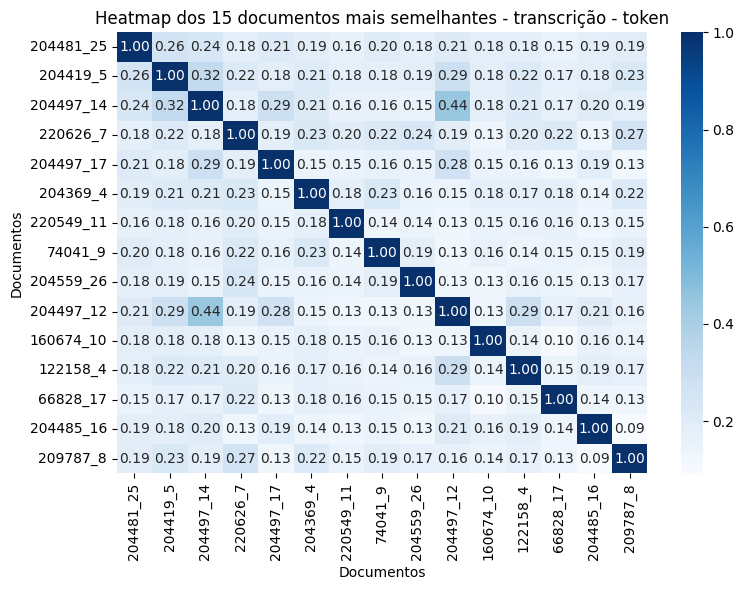

In [21]:
matriz_similaridade_top_n(x_tf_idf_token, doc_ids_tf_idf_token,15, "transcrição - token")

In [22]:
discurso_a = database.get_discurso_by_id(204497,12)
discurso_b = database.get_discurso_by_id(204497, 14)

print(discurso_a["transcricao"])
print('-'*50)
print(discurso_b["transcricao"])

O SR. JÚNIOR FERRARI (PSD - PA. Como Líder. Sem revisão do orador.) - Sr. Presidente, Sras. e Srs. Deputados, eu quero agradecer ao nosso Líder, Deputado André de Paula, a oportunidade do espaço para falar em nome da Liderança do PSD.
Quero parabenizar o Presidente da Câmara, Deputado Rodrigo Maia, pela articulação e empenho na aprovação desta reforma tão importante. Parabenizo toda a equipe da Presidência, os Deputados que votaram no primeiro turno e estão votando no segundo turno essa reforma tão importante para o nosso País.
A reforma da Previdência representa, nos próximos 10 anos, uma economia em torno de 933 bilhões de reais, ou seja, investimentos que vão ser aplicados na saúde, na educação, na segurança pública, em infraestrutura, estradas, rodovias, e outras áreas importantes para o Brasil, para que possamos melhorar a qualidade de vida do povo brasileiro.
Muito mais além, esta reforma da Previdência, além dos 933 bilhões de reais de economia, vai também gerar um efeito positi

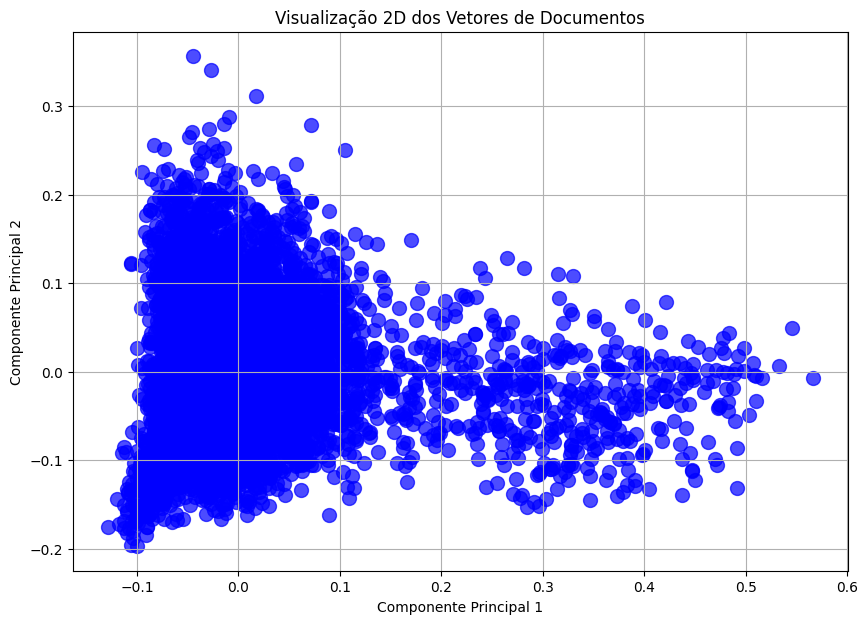

In [23]:
grafico2D(x_tf_idf_token)

In [ ]:
grafico3D(x_tf_idf_token)

### Sumário

#### Tokens

In [ ]:
corpus_sumario_td_idf_token,doc_ids_sumario_tf_idf_token = get_discursos_corpus("sumario_tokens",CAMPOS_ID, QUANTITY)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


##### TF-IDF

In [43]:
x_sumario_tf_idf_token, vec_sumario_td_idf_token = processar_dados_td_idf(corpus_sumario_td_idf_token)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [20]:
mostrar_tabela(x_sumario_tf_idf_token,vec_sumario_td_idf_token,"Matriz Documento-Termo Sumario (TF-IDF)")

Matriz Documento-Termo Sumario (TF-IDF)


,aapdp,aarao,abacateiro,abadeus,abadiania,abads,abafa,abaira,abaixo,abaixoassinados,...,zonas,zoofilia,zoologico,zoonoses,zpe,zpes,zucato,zucco,zuliani,zumbi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9661,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [14]:
search_and_rank(query, vec_sumario_td_idf_token, x_sumario_tf_idf_token, corpus_sumario_td_idf_token, doc_ids_sumario_tf_idf_token, "TF-IDF - sumario - tokens")

Top-3 Similares para a Query (usando TF-IDF - sumario - tokens):
  Doc204419_9 (score=0.306): ['realizacao', 'comissao', 'desenvolvimento', 'economico', 'industria', 'comercio', 'servicos', 'audiencia', 'publica', 'destinada', 'debate', 'relevancia', 's', 'pais']
  Doc178993_2 (score=0.256): ['deputado', 'registrou', 'preocupacao', 'decisao', 'governo', 'interino', 'tocantins', 'demitir', 'jovens', 'contratados', 'programa', 'jovem', 'trabalhador', 'afirmou', 'vagas', 'representavam', 'oportunidades', 'formais', 'emprego', 'criticou', 'transferencia', 'atividades', 's', 'nao', 'oferecia', 'contratacao', 'carteira', 'assinada', 'defendeu', 's', 'deveria', 'investir', 'qualificacao', 'profissional', 'estados', 'nao', 'substituir', 'postos', 'trabalho', 'existentes', 'classificou', 'demissoes', 'prejuizo', 'juventude']
  Doc171623_3 (score=0.250): ['defesa', 'melhoria', 'continuada', 'capacitacao', 'profissional', 'trabalhador', 'brasileiro', 'proporcionada', 'entidades', 'integrantes', '

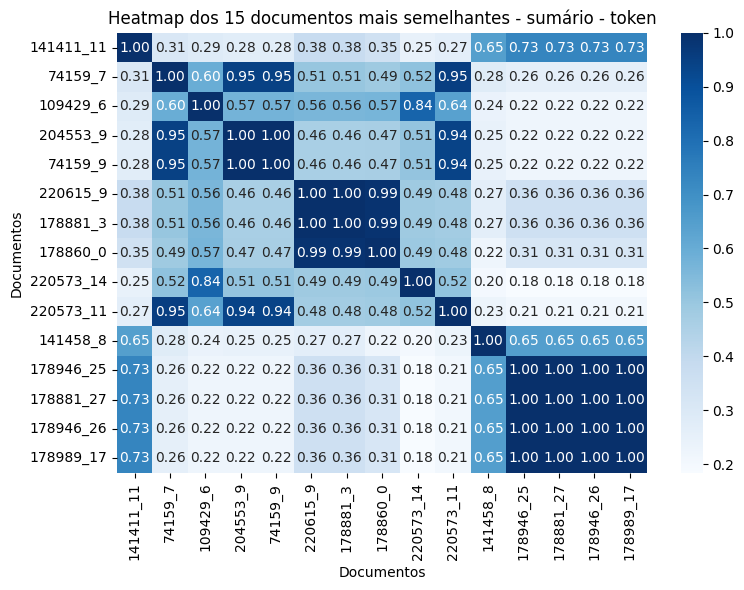

In [40]:
matriz_similaridade_top_n(x_sumario_tf_idf_token, doc_ids_sumario_tf_idf_token, 15, "sumário - token")

In [30]:
discurso_a = database.get_discurso_by_id(204553, 9)
discurso_b = database.get_discurso_by_id(109429, 6)

print(discurso_a["sumario"])
print('-'*50)
print(discurso_b["sumario"])

O Deputado orientou a bancada na votação do requerimento de adiamento da votação da Medida Provisória nº 1.301, de 2025, que institui o Programa Agora Tem Especialistas, dispõe sobre o Grupo Hospitalar Conceição S.A., altera a Lei nº 8.080, de 19 de setembro de 1990, a Lei nº 8.958, de 20 de dezembro de 1994, a Lei nº 9.656, de 3 de junho de 1998, a Lei nº 12.732, de 22 de novembro de 2012, a Lei nº 12.871, de 22 de outubro de 2013, e a Lei nº 13.958, de 18 de dezembro de 2019.
--------------------------------------------------
O Deputado orientou a bancada na votação da Emenda aglutinativa nº 1 da Medida Provisória nº 1.300, de 2025, que altera a Lei nº 9.074, de 7 de julho de 1995, a Lei nº 9.427, de 26 de dezembro de 1996, a Lei nº 10.438, de 26 de abril de 2002, a Lei nº 10.848, de 15 de março de 2004, a Lei nº 12.111, de 9 de dezembro de 2009, a Lei nº 12.212, de 20 de janeiro de 2010, a Lei nº 13.203, de 8 de dezembro de 2015, e a Lei nº 14.300, de 6 de janeiro de 2022 para refor

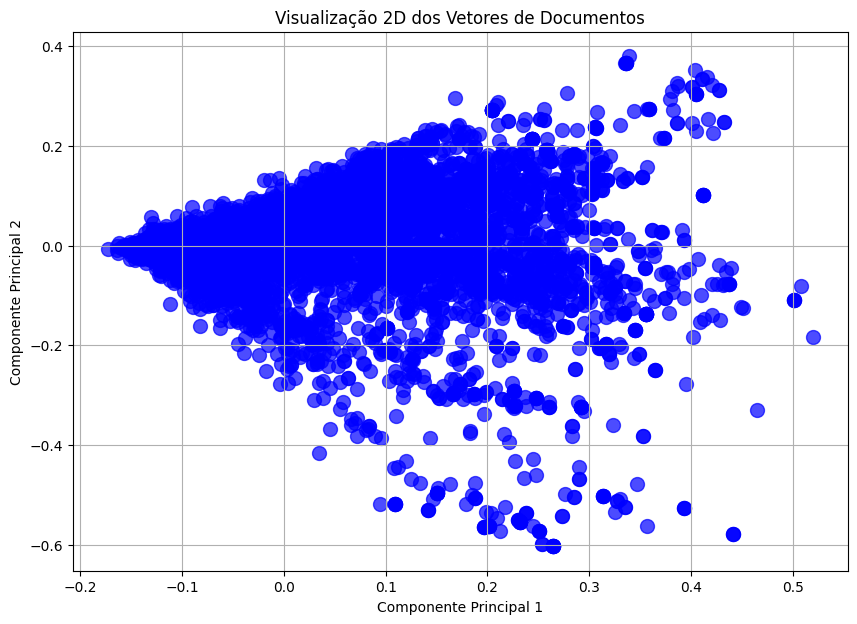

In [16]:
grafico2D(x_sumario_tf_idf_token)

In [15]:
grafico3D(x_sumario_tf_idf_token)

##### Word2Vec


In [31]:
vector_dim = 100 # Dimensão dos vetores
window_size = 5  # Janela de contexto
min_word_count = 1 # Contagem mínima para incluir palavra
num_workers = 4 # Threads para treinamento

model_w2v_sumario_token = Word2Vec(
    sentences=corpus_sumario_td_idf_token,
    vector_size=vector_dim,
    window=window_size,
    min_count=min_word_count,
    workers=num_workers,
    sg=0 # Usando CBOW (padrão), 1 para Skip-gram
)

print(f"Modelo treinado com vocabulário de {len(model_w2v_sumario_token.wv.index_to_key)} palavras.")

Modelo treinado com vocabulário de 20926 palavras.


In [32]:
model_w2v_sumario_token.wv.most_similar("votacao")

[('bancada', 0.9566251635551453),
 ('vetos', 0.9510400891304016),
 ('favoravelmente', 0.9465712308883667),
 ('discussao', 0.945982038974762),
 ('deliberacao', 0.944922924041748),
 ('substitutiva', 0.9421210289001465),
 ('requerimento', 0.9419360160827637),
 ('tramitacao', 0.938630223274231),
 ('requerimentos', 0.9385689496994019),
 ('apresentado', 0.9367423057556152)]

In [45]:
vetores_documentos = calcula_vetor_medio(corpus_sumario_td_idf_token,model_w2v_sumario_token,vector_dim)

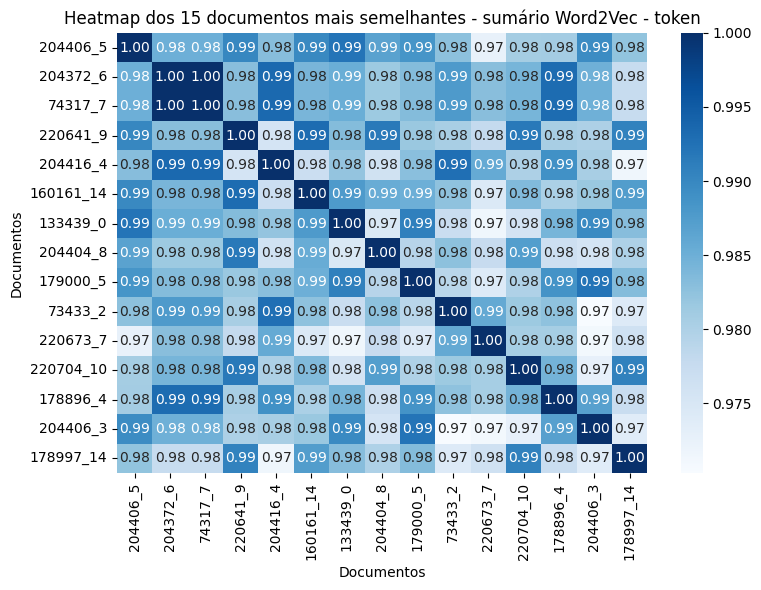

In [46]:
matriz_similaridade_top_n(vetores_documentos, doc_ids_sumario_tf_idf_token, 15, "sumário Word2Vec - token")

In [54]:
# Entrada pelo usuário
termo_busca_usuario = input("Digite os termos de busca para Word2Vec: ")

# Obter as recomendações usando a função
# Você pode definir um número máximo de resultados aqui, se quiser (ex: num_resultados=5)
recomendacoes_df = recomendar_documentos_w2v(
    termo_busca_usuario,
    model_w2v_sumario_token,
    doc_ids_sumario_tf_idf_token,
    vetores_documentos
    # num_resultados=5 # Descomente para limitar a 5 resultados
)

print(f"termo pesquisado: {termo_busca_usuario}")

# Exibir o DataFrame resultante
if not recomendacoes_df.empty:
    print("Ok")
else:
    print("Nenhuma recomendação encontrada para o termo de busca.")

recomendacoes_df

termo pesquisado: reforma previdencia
Ok


,Documento,Similaridade
0,220557_6,0.939534
1,204427_14,0.929448
2,178895_6,0.919091
3,220561_11,0.917639
4,204486_26,0.914760
...,...,...
9661,178983_16,0.081567
9662,74646_7,0.081197
9663,160976_0,0.071136
9664,178964_22,0.063340


In [ ]:
# 1. Preparar DataFrame Inicial (se ainda não existir)
df_w2v_docs = pd.DataFrame({'Documento Original': doc_ids_sumario_tf_idf_token})

# 2. Aplicar KMeans
# Definindo o número de clusters (pode ser ajustado/otimizado)
num_clusters = 5 # Você pode experimentar outros valores

# Aplicando o KMeans aos vetores Word2Vec
# Adicionar n_init=10 para evitar warnings e melhorar a robustez
kmeans_w2v = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)

# O fit é feito diretamente nos vetores Word2Vec (que já são densos)
kmeans_w2v.fit(vetores_documentos)

# Adicionando as labels (rótulos) dos clusters ao DataFrame
df_w2v_docs['Cluster'] = kmeans_w2v.labels_

# Exibindo uma amostra dos documentos e seus clusters atribuidos
print(f"\nAmostra de Documentos e Clusters (KMeans com {num_clusters} clusters):")
df_w2v_docs[['Documento Original', 'Cluster']]



Amostra de Documentos e Clusters (KMeans com 3 clusters):


,Documento Original,Cluster
0,72442_0,0
1,72442_1,0
2,72442_2,0
3,72442_3,2
4,72442_4,0
...,...,...
9661,220612_27,2
9662,220612_28,2
9663,220686_15,0
9664,220686_16,0


#### Lematização

In [28]:
corpus_sumario_td_idf_lem,doc_ids_sumario_tf_idf_lem = get_discursos_corpus("sumario_lemizado",CAMPOS_ID, QUANTITY)
x_sumario_tf_idf_lem, vec_sumario_td_idf_lem = processar_dados_td_idf(corpus_sumario_td_idf_lem)

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [25]:
mostrar_tabela(x_sumario_tf_idf_lem,vec_sumario_td_idf_lem,"Matriz Documento-Termo Sumario (TF-IDF)")

Matriz Documento-Termo Sumario (TF-IDF)


,Abandono,Abgd,Abmes,Abner,Aborto,Abrange,Abrao,Abu,Ac,Acai,...,zoofilia,zoologico,zoonoses,zpe,zpes,zucato,zucco,zulianir,zumbi,zumbir
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9661,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9662,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9663,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9664,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


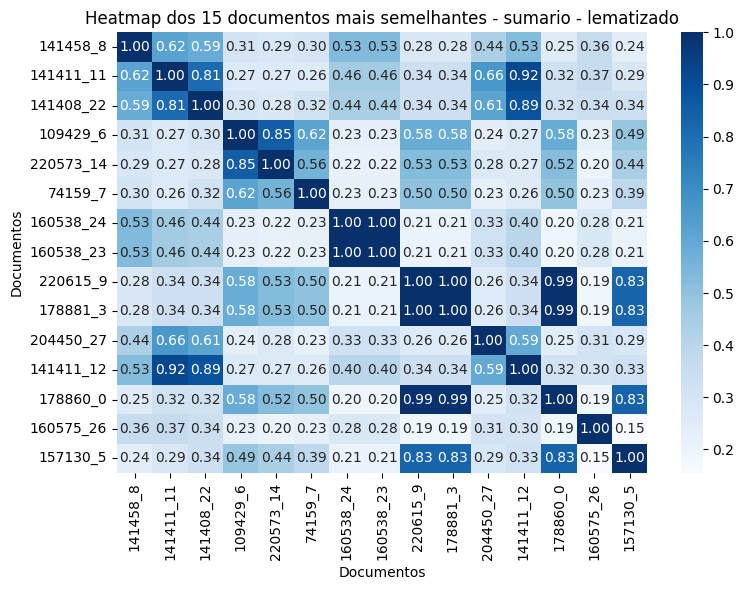

In [24]:
matriz_similaridade_top_n(x_sumario_tf_idf_lem, doc_ids_sumario_tf_idf_lem,15, "sumario - lematizado")

In [26]:
search_and_rank(query, vec_sumario_td_idf_lem, x_sumario_tf_idf_lem, corpus_sumario_td_idf_lem, doc_ids_sumario_tf_idf_lem, "TF-IDF - sumario - lem")

Top-3 Similares para a Query (usando TF-IDF - sumario - lem):
  Doc204419_9 (score=0.310): ['realizacao', 'comissao', 'desenvolvimento', 'economico', 'industrio', 'Comercio', 'servico', 'audiencia', 'publico', 'destinar', 'debate', 'relevancia', 's', 'pai']
  Doc171623_3 (score=0.290): ['defesa', 'melhoria', 'continuar', 'capacitacao', 'profissional', 'trabalhador', 'brasileiro', 'proporcionar', 'entidade', 'integrante', 'chamar', 's']
  Doc178993_2 (score=0.264): ['deputado', 'registrar', 'preocupacao', 'decisao', 'governo', 'interino', 'tocantim', 'demitir', 'jovem', 'contratar', 'programa', 'jovem', 'trabalhador', 'afirmar', 'vaga', 'representar', 'oportunidade', 'formal', 'emprego', 'criticar', 'transferencia', 'atividade', 's', 'nao', 'oferecia', 'contratacao', 'carteiro', 'assinar', 'defender', 's', 'dever', 'investir', 'qualificacao', 'profissional', 'estados', 'nao', 'substituir', 'posto', 'trabalho', 'existente', 'classificar', 'demissoes', 'prejuizar', 'Juventude']
----------

In [ ]:
discurso_a = database.get_discurso_by_id(220573, 11)
discurso_b = database.get_discurso_by_id(74159, 9)

print(discurso_a["sumario"])
print('-'*50)
print(discurso_b["sumario"])